In [1]:
import pandas as pd
import numpy as np
import glob
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor

In [2]:
crop_horizon = {

    # Vegetables
    "Beans": 3, "Beetroot": 3, "Brinjal": 4, "Cabbage": 4,
    "Capsicum": 4, "Carrot": 3, "Cauliflower": 4, "Colacasia": 4,
    "Drumstick": 4, "Green Chilli": 4, "Green Peas": 3,
    "Leafy Vegetable": 2, "Onion Green": 2, "Peas Wet": 3,
    "Pumpkin": 4, "Raddish": 2, "Rajgir": 3,
    "Sweet Potato": 4, "Tinda": 3, "Tomato": 4, "Water Melon": 3,

    # Medium crops
    "Ajwan": 4, "Amaranthus": 3, "Castor Seed": 6,
    "Chili Red": 5, "Dry Chillies": 5, "Garlic": 6,
    "Ground Nut Seed": 5, "Groundnut": 5, "Guar": 4,
    "Maize": 4, "Methi Seeds": 4, "Moath Dal": 4,
    "Mustard": 5, "Onion": 5, "Tobacco": 6, "Wheat": 5,

    # Fruits
    "Apple": 6, "Banana": 8, "Guava": 6, "Mango": 6,
    "Orange": 6, "Papaya": 8, "Pomegranate": 6,

    # Fibre & spice
    "Cotton": 6, "Soanf": 4,
}

In [3]:
processed_path = "/mnt/d/SEM_six_SGP/Crop_Price_V2/processed"

files = glob.glob(os.path.join(processed_path, "*.csv"))
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values(["commodity", "district", "date"]).reset_index(drop=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (87053, 28)


In [4]:
df["volatility_12"] = (
    df.groupby(["commodity","district"])["monthly_mean_price"]
      .shift(1)
      .rolling(12)
      .std()
)

In [5]:
df["momentum_1"] = (
    df.groupby(["commodity","district"])["monthly_mean_price"]
      .pct_change(1)
)

df["momentum_3"] = (
    df.groupby(["commodity","district"])["monthly_mean_price"]
      .pct_change(3)
)

In [6]:
epsilon = 1e-10

df["price_ratio_1"] = df["monthly_mean_price"] / (df["price_lag_1"] + epsilon)
df["price_ratio_3"] = df["monthly_mean_price"] / (df["price_lag_3"] + epsilon)

In [7]:
rain_normal = df.groupby(["district","month"])["monthly_rain_sum"].transform("mean")
df["rain_anomaly"] = df["monthly_rain_sum"] - rain_normal

In [8]:
df["ndvi_momentum_3"] = (
    df.groupby(["commodity","district"])["monthly_ndvi_mean"]
      .pct_change(3)
)

In [9]:
df["horizon"] = df["commodity"].map(crop_horizon)

In [10]:
def compute_harvest_avg(group):
    prices = group["monthly_mean_price"].values
    horizons = group["horizon"].values
    harvest_avg = []

    for i in range(len(group)):
        h = int(horizons[i])

        if i + h + 1 < len(group):
            avg_price = np.mean(prices[i + h : i + h + 2])
        else:
            avg_price = np.nan

        harvest_avg.append(avg_price)

    group["future_price"] = harvest_avg
    return group

df = df.groupby(["commodity","district"], group_keys=False).apply(compute_harvest_avg)

/tmp/ipykernel_491/4008664797.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["commodity","district"], group_keys=False).apply(compute_harvest_avg)


In [11]:
df["target_return"] = np.log(
    (df["future_price"] + epsilon) /
    (df["monthly_mean_price"] + epsilon)
)

In [12]:
df = df.dropna().reset_index(drop=True)

In [13]:
##ENCODING

In [14]:
le_district = LabelEncoder()
le_commodity = LabelEncoder()

df["district_enc"] = le_district.fit_transform(df["district"])
df["commodity_enc"] = le_commodity.fit_transform(df["commodity"])

In [15]:
##TIME SPLIT

In [16]:
train = df[df["date"] < "2023-01-01"]
valid = df[(df["date"] >= "2023-01-01") & (df["date"] < "2024-01-01")]
test  = df[df["date"] >= "2025-01-01"]

DROP_COLS = [
    "district",
    "commodity",
    "date",
    "future_price",
    "target_return",
    "target_price"
]

X_train = train.drop(columns=DROP_COLS)
y_train = train["target_return"]

X_valid = valid.drop(columns=DROP_COLS)
y_valid = valid["target_return"]

X_test = test.drop(columns=DROP_COLS)
y_test = test["target_return"]

In [17]:
model = LGBMRegressor(
    n_estimators=2500,
    learning_rate=0.02,
    num_leaves=128,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011704 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6881
[LightGBM] [Info] Number of data points in the train set: 65464, number of used features: 34
[LightGBM] [Info] Start training from score 0.050773


,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.02
,n_estimators,2500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [18]:
val_return_pred = model.predict(X_valid)
test_return_pred = model.predict(X_test)

val_price_pred = valid["monthly_mean_price"] * np.exp(val_return_pred)
test_price_pred = test["monthly_mean_price"] * np.exp(test_return_pred)

In [19]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    epsilon = 1e-10
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    r2 = r2_score(y_true, y_pred)

    print("RMSE:", round(rmse,2))
    print("MAE:", round(mae,2))
    print("MAPE:", round(mape,2), "%")
    print("R2:", round(r2,4))

print("Validation Performance")
evaluate(valid["future_price"], val_price_pred)

print("\nTest Performance")
evaluate(test["future_price"], test_price_pred)

Validation Performance
RMSE: 1838.71
MAE: 903.65
MAPE: 20.31 %
R2: 0.7143

Test Performance
RMSE: 1183.95
MAE: 744.22
MAPE: 19.95 %
R2: 0.8058


In [42]:
import os

MODEL_DIR = "/mnt/d/SEM_six_SGP/Crop_Price_V2/production_model"
os.makedirs(MODEL_DIR, exist_ok=True)

In [43]:
import joblib

joblib.dump(model, os.path.join(MODEL_DIR, "crop_price_model.pkl"))

['/mnt/d/SEM_six_SGP/Crop_Price_V2/production_model/crop_price_model.pkl']

In [44]:
joblib.dump(le_district, os.path.join(MODEL_DIR, "district_encoder.pkl"))
joblib.dump(le_commodity, os.path.join(MODEL_DIR, "commodity_encoder.pkl"))

['/mnt/d/SEM_six_SGP/Crop_Price_V2/production_model/commodity_encoder.pkl']

In [45]:
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, os.path.join(MODEL_DIR, "feature_columns.pkl"))

['/mnt/d/SEM_six_SGP/Crop_Price_V2/production_model/feature_columns.pkl']

In [46]:
joblib.dump(crop_horizon, os.path.join(MODEL_DIR, "crop_horizon.pkl"))

['/mnt/d/SEM_six_SGP/Crop_Price_V2/production_model/crop_horizon.pkl']

In [47]:
metadata = {
    "model_type": "LightGBM",
    "horizon_type": "crop_specific_harvest_window",
    "target": "log_return",
    "train_until": "2021-12-31",
    "validation_period": "2022",
    "test_period": "2023+",
    "mape_test": 19.82,
    "r2_test": 0.81
}

joblib.dump(metadata, os.path.join(MODEL_DIR, "model_metadata.pkl"))

['/mnt/d/SEM_six_SGP/Crop_Price_V2/production_model/model_metadata.pkl']

In [ ]:
### testing

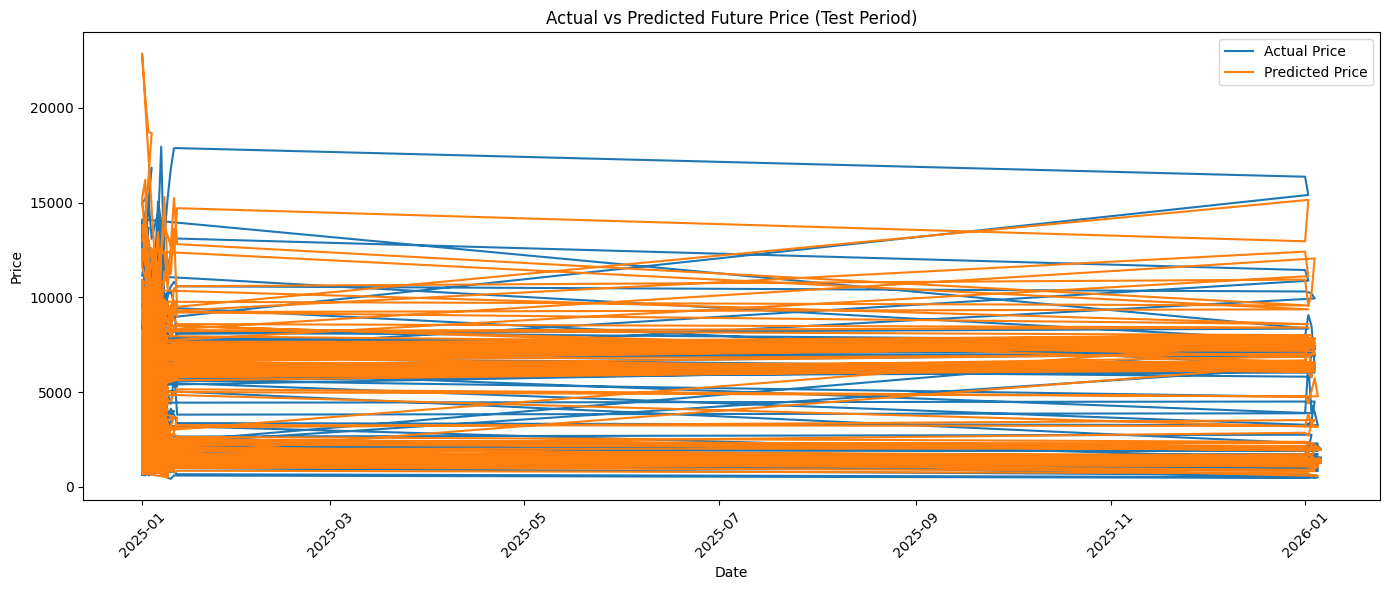

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(test["date"], test["future_price"], label="Actual Price")
plt.plot(test["date"], test_price_pred, label="Predicted Price")

plt.title("Actual vs Predicted Future Price (Test Period)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

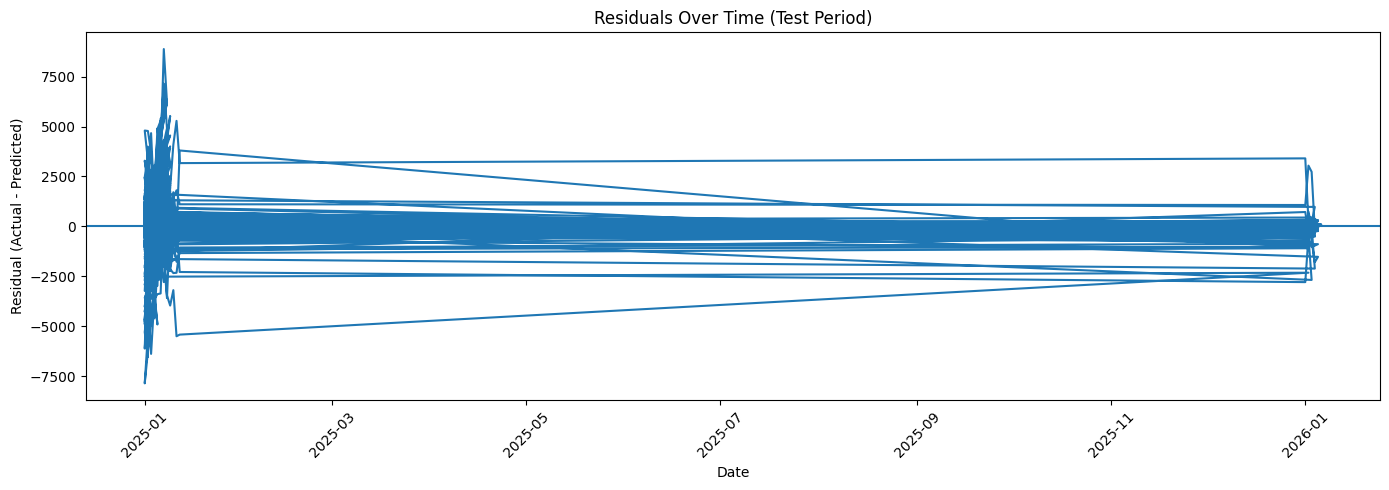

In [21]:
residuals = test["future_price"] - test_price_pred

plt.figure(figsize=(14,5))
plt.plot(test["date"], residuals)

plt.axhline(0)
plt.title("Residuals Over Time (Test Period)")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

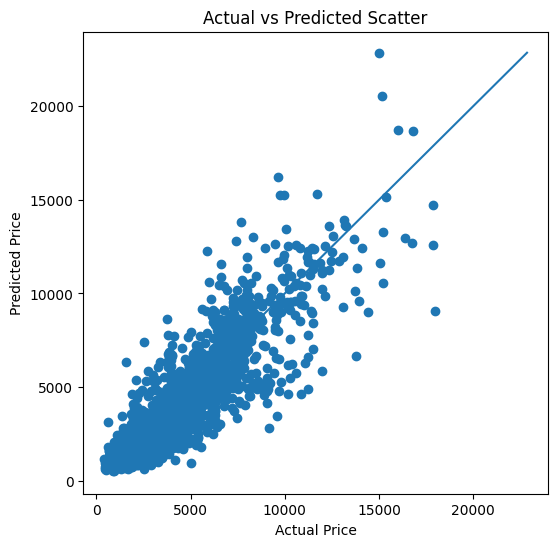

In [22]:
plt.figure(figsize=(6,6))

plt.scatter(test["future_price"], test_price_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Scatter")

# Diagonal line
min_val = min(test["future_price"].min(), test_price_pred.min())
max_val = max(test["future_price"].max(), test_price_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

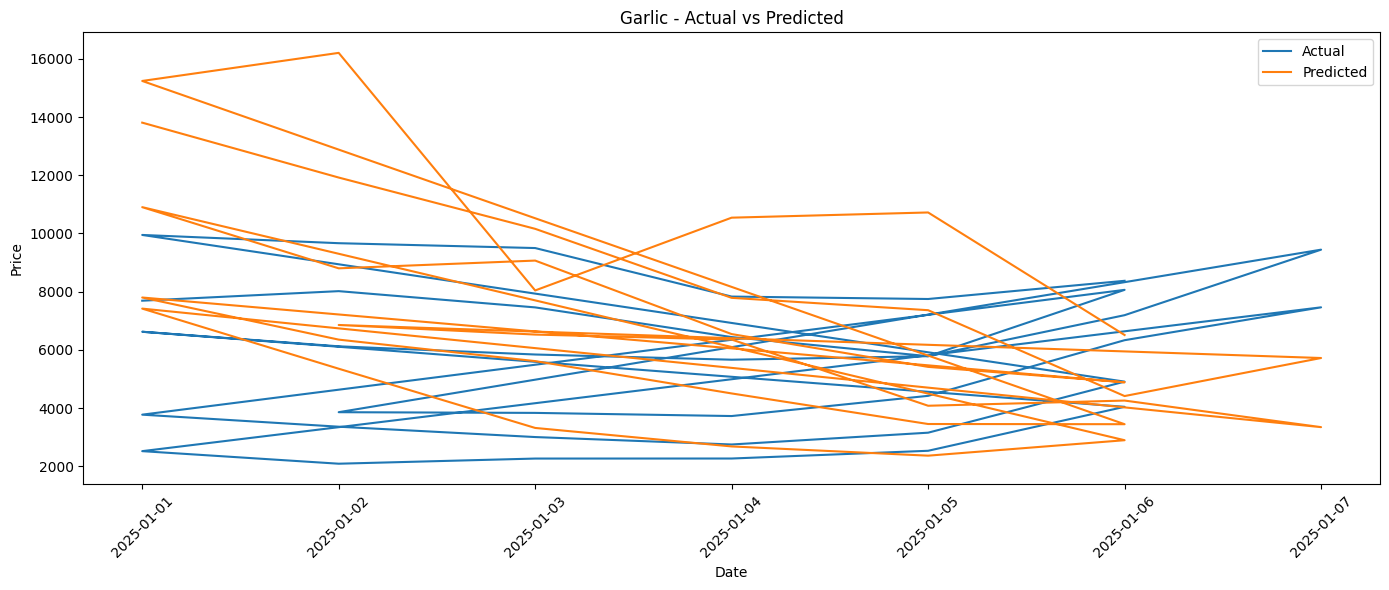

In [23]:
crop_name = "Garlic"

crop_test = test[test["commodity"] == crop_name]
crop_pred = test_price_pred[test["commodity"] == crop_name]

plt.figure(figsize=(14,6))

plt.plot(crop_test["date"], crop_test["future_price"], label="Actual")
plt.plot(crop_test["date"], crop_pred, label="Predicted")

plt.title(f"{crop_name} - Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

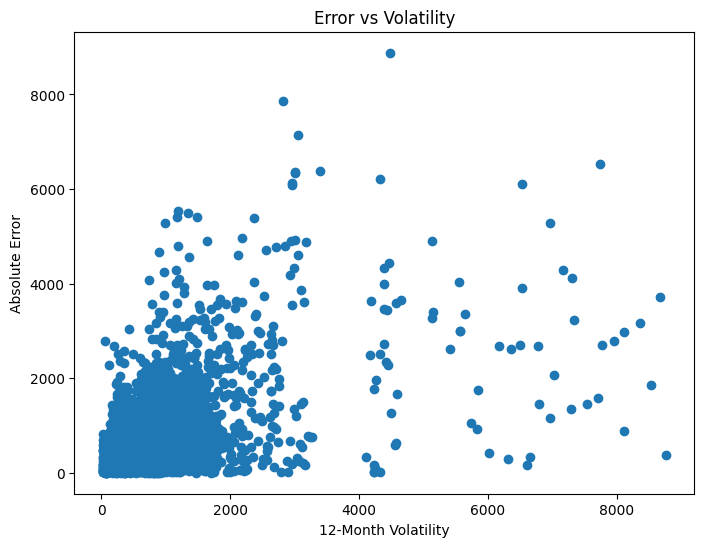

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(test["volatility_12"], abs(residuals))

plt.xlabel("12-Month Volatility")
plt.ylabel("Absolute Error")
plt.title("Error vs Volatility")

plt.show()

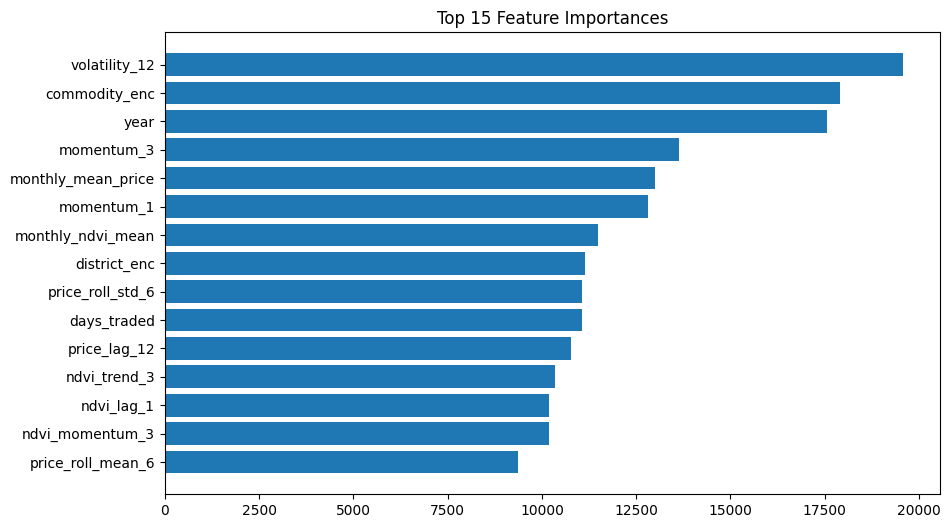

In [25]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"][:15], importance_df["Importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

In [26]:
!pip install shap


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


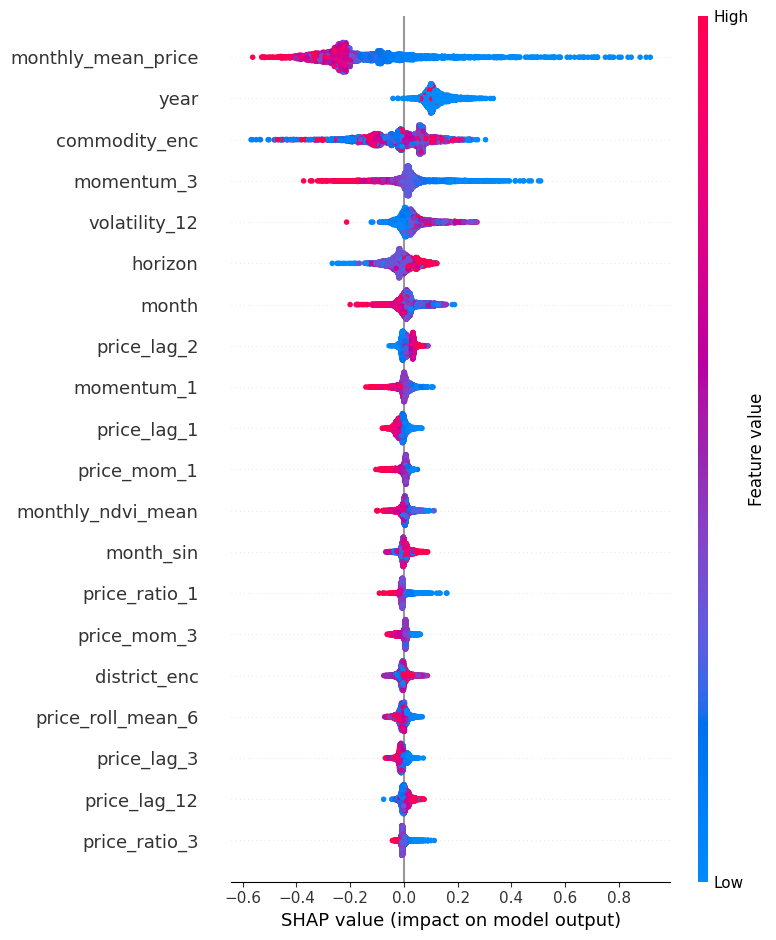

In [27]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42
)

xgb_model.fit(X_train, y_train_log)

val_pred_xgb = np.expm1(xgb_model.predict(X_valid))
test_pred_xgb = np.expm1(xgb_model.predict(X_test))

print("XGBoost Validation")
evaluate(y_valid, val_pred_xgb)

print("\nXGBoost Test")
evaluate(y_test, test_pred_xgb)

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train_log)

val_pred_rf = np.expm1(rf_model.predict(X_valid))
test_pred_rf = np.expm1(rf_model.predict(X_test))

print("Random Forest Validation")
evaluate(y_valid, val_pred_rf)

print("\nRandom Forest Test")
evaluate(y_test, test_pred_rf)

In [ ]:
lgb_model = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=-1,
    random_state=42
)

lgb_model.fit(X_train, y_train_log)

val_pred_lgb = np.expm1(lgb_model.predict(X_valid))
test_pred_lgb = np.expm1(lgb_model.predict(X_test))

print("LightGBM Validation")
evaluate(y_valid, val_pred_lgb)

print("\nLightGBM Test")
evaluate(y_test, test_pred_lgb)